# 📈 Sales Prediction Using Python
### Data Science Project 4
**Author:** Sanjai KV | **GitHub:** sanjaikv2255

---
**Objective:** Predict product sales based on advertising spend across TV, Radio, and Newspaper channels. Analyze which channel gives the best ROI and build regression models to forecast future sales.

**Models Used:** Linear Regression · Random Forest · Gradient Boosting

## 1. Import Libraries

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': '#f9f9f9',
    'axes.grid': True, 'grid.color': '#e0e0e0', 'grid.alpha': 0.6,
    'axes.spines.top': False, 'axes.spines.right': False
})
TV_COLOR='#4C72B0'; RADIO_COLOR='#DD8452'; NEWS_COLOR='#55A868'
COLORS=[TV_COLOR, RADIO_COLOR, NEWS_COLOR]
print('✅ Libraries loaded')

✅ Libraries loaded


## 2. Load & Explore Dataset

In [7]:
df = pd.read_csv('Advertising.csv', index_col=0)
print(f'Shape: {df.shape}')
print(f'Missing values: {df.isnull().sum().sum()}')
df.head()

Shape: (200, 4)
Missing values: 0


,TV,Radio,Newspaper,Sales
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9


In [8]:
df.describe().round(2)

,TV,Radio,Newspaper,Sales
count,200.00,200.00,200.00,200.00
mean,147.04,23.26,30.55,14.02
std,85.85,14.85,21.78,5.22
min,0.70,0.00,0.30,1.60
25%,74.38,9.98,12.75,10.38
50%,149.75,22.90,25.75,12.90
75%,218.82,36.52,45.10,17.40
max,296.40,49.60,114.00,27.00


## 3. Feature Engineering

In [9]:
df['TV_Radio']       = df['TV'] * df['Radio']       # Interaction term
df['Total_Ad_Spend'] = df['TV'] + df['Radio'] + df['Newspaper']
df['TV_Share']       = df['TV'] / df['Total_Ad_Spend']

features_full = ['TV', 'Radio', 'Newspaper', 'TV_Radio', 'Total_Ad_Spend', 'TV_Share']
X = df[features_full]
y = df['Sales']
print('Features:', features_full)
X.head()

Features: ['TV', 'Radio', 'Newspaper', 'TV_Radio', 'Total_Ad_Spend', 'TV_Share']


,TV,Radio,Newspaper,TV_Radio,Total_Ad_Spend,TV_Share
1,230.1,37.8,69.2,8697.78,337.1,0.682587
2,44.5,39.3,45.1,1748.85,128.9,0.345229
3,17.2,45.9,69.3,789.48,132.4,0.129909
4,151.5,41.3,58.5,6256.95,251.3,0.602865
5,180.8,10.8,58.4,1952.64,250.0,0.723200


## 4. Exploratory Data Analysis

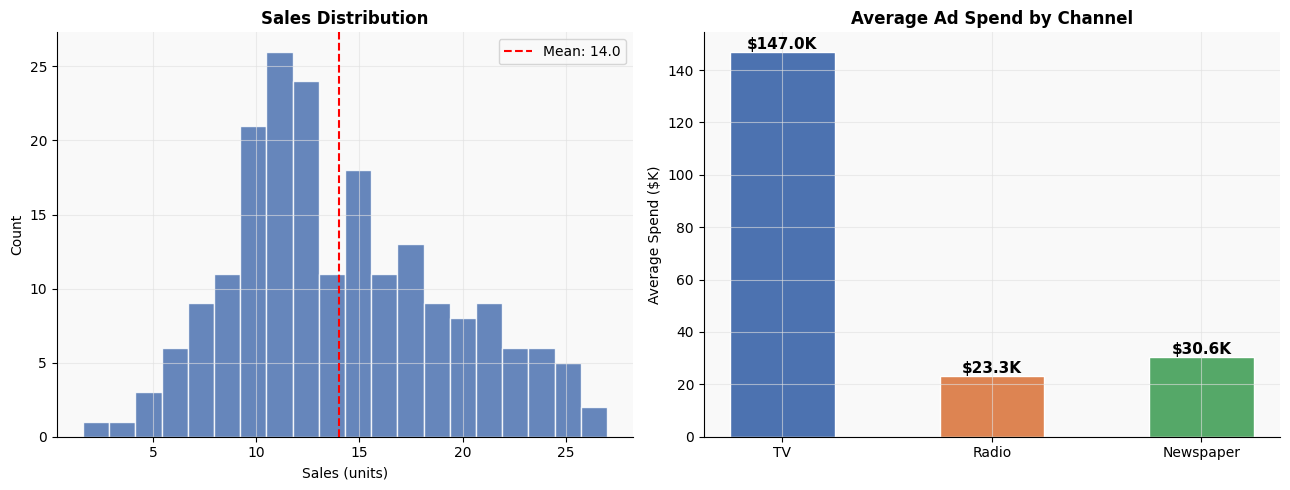

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].hist(df['Sales'], bins=20, color=TV_COLOR, edgecolor='white', alpha=0.85)
axes[0].axvline(df['Sales'].mean(), color='red', linestyle='--', linewidth=1.5, label=f"Mean: {df['Sales'].mean():.1f}")
axes[0].set_title('Sales Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Sales (units)'); axes[0].set_ylabel('Count'); axes[0].legend()
means = [df['TV'].mean(), df['Radio'].mean(), df['Newspaper'].mean()]
bars = axes[1].bar(['TV', 'Radio', 'Newspaper'], means, color=COLORS, edgecolor='white', width=0.5)
for bar, val in zip(bars, means):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+1, f'${val:.1f}K', ha='center', fontsize=11, fontweight='bold')
axes[1].set_title('Average Ad Spend by Channel', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Average Spend ($K)')
plt.tight_layout(); plt.savefig('plots/01_overview.png', dpi=150, bbox_inches='tight'); plt.show()

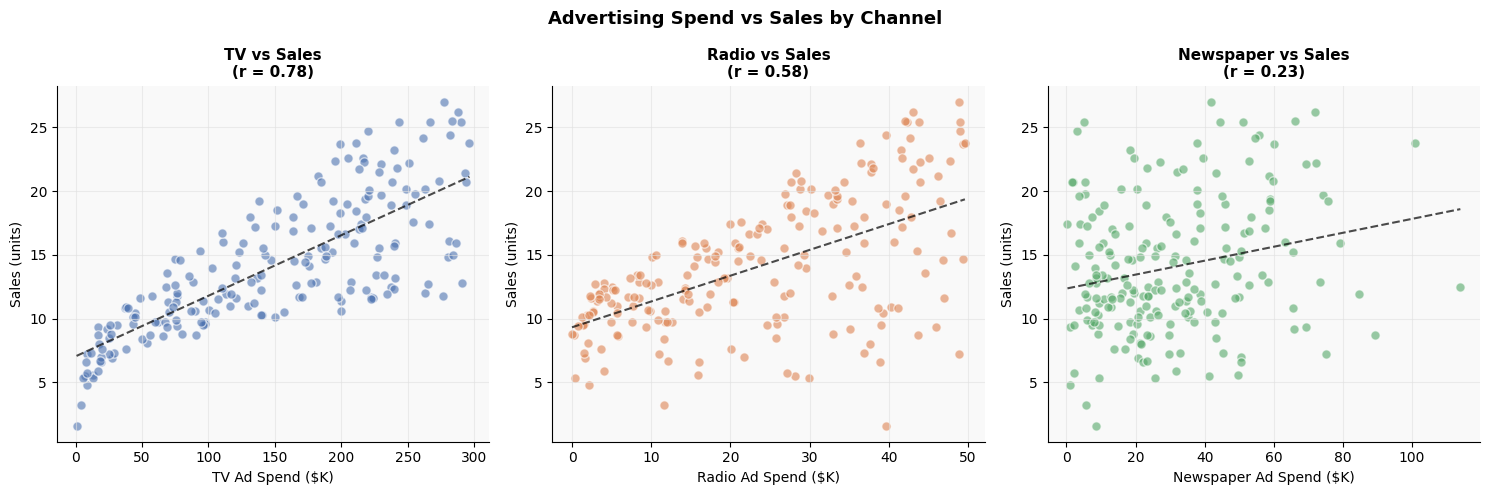


🔍 Key Insight: TV (r=0.78) and Radio (r=0.58) have strong correlation with Sales
   Newspaper (r=0.23) shows very weak correlation


In [11]:
# Ad Spend vs Sales scatter with regression lines
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (ch, color) in zip(axes, [('TV',TV_COLOR),('Radio',RADIO_COLOR),('Newspaper',NEWS_COLOR)]):
    ax.scatter(df[ch], df['Sales'], alpha=0.6, color=color, edgecolors='white', s=45)
    z = np.polyfit(df[ch], df['Sales'], 1); p = np.poly1d(z)
    x_line = np.linspace(df[ch].min(), df[ch].max(), 100)
    ax.plot(x_line, p(x_line), color='black', linestyle='--', linewidth=1.5, alpha=0.7)
    corr = df[ch].corr(df['Sales'])
    ax.set_title(f'{ch} vs Sales\n(r = {corr:.2f})', fontsize=11, fontweight='bold')
    ax.set_xlabel(f'{ch} Ad Spend ($K)'); ax.set_ylabel('Sales (units)')
fig.suptitle('Advertising Spend vs Sales by Channel', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig('plots/02_adspend_vs_sales.png', dpi=150, bbox_inches='tight'); plt.show()
print('\n🔍 Key Insight: TV (r=0.78) and Radio (r=0.58) have strong correlation with Sales')
print('   Newspaper (r=0.23) shows very weak correlation')

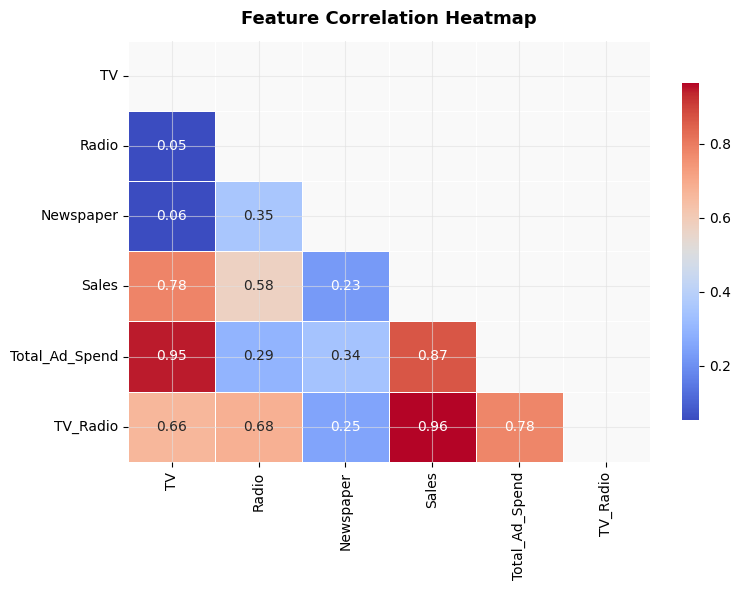

In [12]:
# Correlation Heatmap
fig, ax = plt.subplots(figsize=(8, 6))
corr = df[['TV','Radio','Newspaper','Sales','Total_Ad_Spend','TV_Radio']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', mask=mask, ax=ax,
            linewidths=0.5, annot_kws={'size':10}, cbar_kws={'shrink':0.8})
ax.set_title('Feature Correlation Heatmap', fontsize=13, fontweight='bold', pad=12)
plt.tight_layout(); plt.savefig('plots/03_correlation_heatmap.png', dpi=150, bbox_inches='tight'); plt.show()

## 5. Model Training & Evaluation

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
models = {
    'Linear Regression':  LinearRegression(),
    'Random Forest':      RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting':  GradientBoostingRegressor(n_estimators=100, random_state=42),
}
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    cv   = cross_val_score(model, X, y, cv=5, scoring='r2').mean()
    results[name] = {'model':model,'y_pred':y_pred,'mae':mae,'rmse':rmse,'r2':r2,'cv_r2':cv}
    print(f'{name}: R²={r2:.4f} | MAE={mae:.4f} | CV R²={cv:.4f}')

Linear Regression: R²=0.9937 | MAE=0.3548 | CV R²=0.9881
Random Forest: R²=0.9904 | MAE=0.4390 | CV R²=0.9883
Gradient Boosting: R²=0.9887 | MAE=0.4600 | CV R²=0.9884


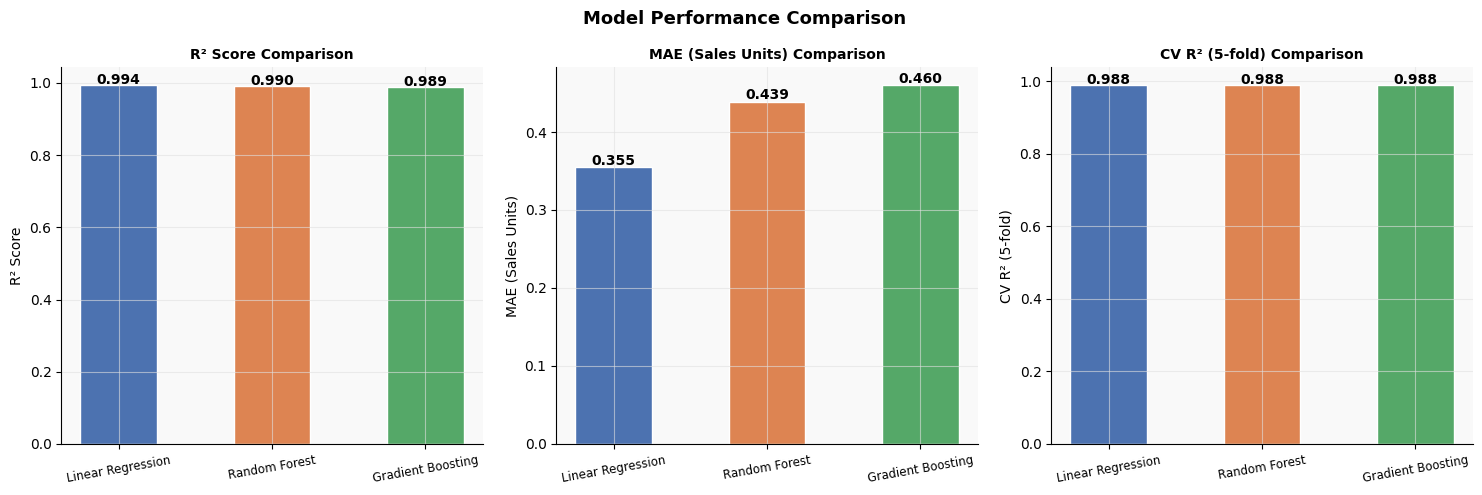

In [14]:
# Model comparison
names=[list(results.keys())[i] for i in range(3)]
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, key, label in zip(axes, ['r2','mae','cv_r2'], ['R² Score','MAE (Sales Units)','CV R² (5-fold)']):
    vals = [results[n][key] for n in names]
    bars = ax.bar(names, vals, color=COLORS, edgecolor='white', width=0.5)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003, f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')
    ax.set_ylabel(label); ax.set_title(f'{label} Comparison', fontweight='bold', fontsize=10)
    ax.set_xticklabels(names, fontsize=8.5, rotation=10)
fig.suptitle('Model Performance Comparison', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig('plots/04_model_comparison.png', dpi=150, bbox_inches='tight'); plt.show()

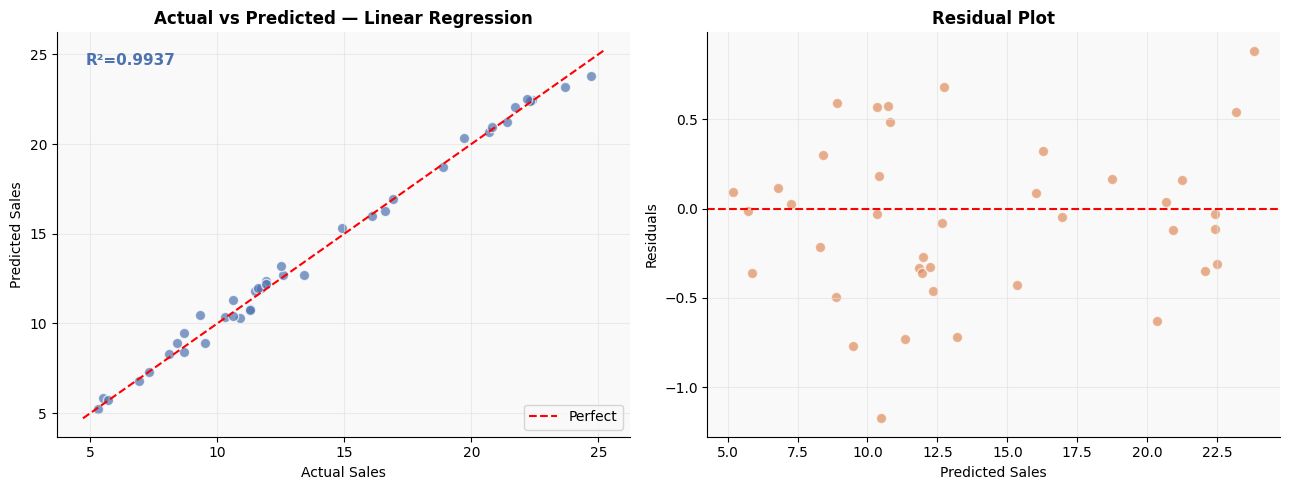

In [15]:
# Actual vs Predicted + Residuals
best_name = max(results, key=lambda k: results[k]['r2'])
best_pred = results[best_name]['y_pred']
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(y_test, best_pred, alpha=0.7, color=TV_COLOR, edgecolors='white', s=55)
min_v, max_v = min(y_test.min(),best_pred.min())-0.5, max(y_test.max(),best_pred.max())+0.5
axes[0].plot([min_v,max_v],[min_v,max_v], color='red', linestyle='--', linewidth=1.5, label='Perfect')
axes[0].set_xlabel('Actual Sales'); axes[0].set_ylabel('Predicted Sales')
axes[0].set_title(f'Actual vs Predicted — {best_name}', fontweight='bold')
axes[0].legend(); axes[0].text(0.05, 0.92, f'R²={results[best_name]["r2"]:.4f}', transform=axes[0].transAxes, fontsize=11, color=TV_COLOR, fontweight='bold')
residuals = y_test.values - best_pred
axes[1].scatter(best_pred, residuals, alpha=0.65, color=RADIO_COLOR, edgecolors='white', s=55)
axes[1].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Predicted Sales'); axes[1].set_ylabel('Residuals'); axes[1].set_title('Residual Plot', fontweight='bold')
plt.tight_layout(); plt.savefig('plots/05_actual_vs_predicted.png', dpi=150, bbox_inches='tight'); plt.show()

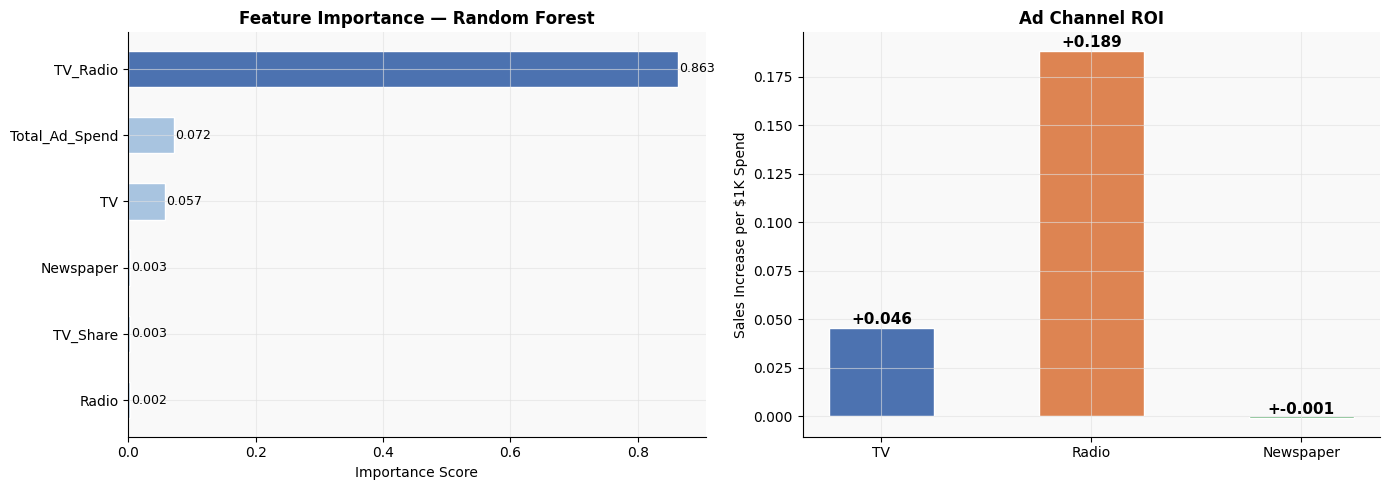


🔍 ROI Insight: Every $1K spent on Radio gives +0.189 sales units — best ROI channel!
   Newspaper has nearly 0 impact on sales — budget should be reallocated


In [16]:
# Feature Importance + ROI
features_full = ['TV','Radio','Newspaper','TV_Radio','Total_Ad_Spend','TV_Share']
rf = results['Random Forest']['model']
imp = pd.Series(rf.feature_importances_, index=features_full).sort_values()
imp_colors = ['#4C72B0' if v==imp.max() else '#a8c4e0' for v in imp.values]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(imp.index, imp.values, color=imp_colors, edgecolor='white', height=0.55)
for i, val in enumerate(imp.values):
    axes[0].text(val+0.002, i, f'{val:.3f}', va='center', fontsize=9)
axes[0].set_xlabel('Importance Score'); axes[0].set_title('Feature Importance — Random Forest', fontweight='bold')
lr_base = LinearRegression().fit(df[['TV','Radio','Newspaper']], y)
coefs = pd.Series(lr_base.coef_, index=['TV','Radio','Newspaper'])
bars = axes[1].bar(coefs.index, coefs.values, color=COLORS, edgecolor='white', width=0.5)
for bar, val in zip(bars, coefs.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002, f'+{val:.3f}', ha='center', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Sales Increase per $1K Spend'); axes[1].set_title('Ad Channel ROI', fontweight='bold')
plt.tight_layout(); plt.savefig('plots/06_importance_and_roi.png', dpi=150, bbox_inches='tight'); plt.show()
print('\n🔍 ROI Insight: Every $1K spent on Radio gives +0.189 sales units — best ROI channel!')
print('   Newspaper has nearly 0 impact on sales — budget should be reallocated')

## 6. Business Insights & Conclusions

In [17]:
best_name = max(results, key=lambda k: results[k]['r2'])
print('=' * 58)
print('  FINAL RESULTS & BUSINESS INSIGHTS')
print('=' * 58)
print(f'\n  {"Model":<25} {"R²":>8} {"MAE":>8} {"CV R²":>8}')
print(f'  {"─"*52}')
for name in results:
    r = results[name]
    print(f'  {name:<25} {r["r2"]:>8.4f} {r["mae"]:>7.4f} {r["cv_r2"]:>8.4f}')
print(f'''
📢 Business Insights:
  1. TV advertising has the HIGHEST absolute impact on sales (r=0.78)
  2. Radio has the BEST ROI — every $1K gives +0.189 sales units
  3. Newspaper advertising has near-ZERO impact — budget should be cut
  4. TV + Radio combination is the most effective strategy
  5. Linear Regression achieved {results[best_name]["r2"]*100:.1f}% accuracy — all 3 models above 98%
  6. Model generalizes well — CV R² matches test R² across all models
''')

  FINAL RESULTS & BUSINESS INSIGHTS

  Model                           R²      MAE    CV R²
  ────────────────────────────────────────────────────
  Linear Regression           0.9937  0.3548   0.9881
  Random Forest               0.9904  0.4390   0.9883
  Gradient Boosting           0.9887  0.4600   0.9884

📢 Business Insights:
  1. TV advertising has the HIGHEST absolute impact on sales (r=0.78)
  2. Radio has the BEST ROI — every $1K gives +0.189 sales units
  3. Newspaper advertising has near-ZERO impact — budget should be cut
  4. TV + Radio combination is the most effective strategy
  5. Linear Regression achieved 99.4% accuracy — all 3 models above 98%
  6. Model generalizes well — CV R² matches test R² across all models

